In [38]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T

### 对图片进行处理

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=690x690 at 0x1CE2203C5C0>
(690, 690)


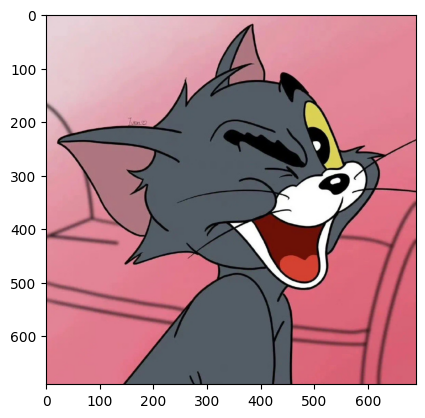

In [39]:
img = Image.open("./img/test.jpg")
print(img)
print(img.size)
# print(img.shape)
plt.imshow(img)

tensor([[[0.8980, 0.8941, 0.8941,  ..., 0.8824, 0.8824, 0.8824],
         [0.8941, 0.8902, 0.8941,  ..., 0.8824, 0.8824, 0.8824],
         [0.8941, 0.8941, 0.8941,  ..., 0.8902, 0.8863, 0.8824],
         ...,
         [0.8784, 0.8784, 0.8784,  ..., 0.8431, 0.8431, 0.8431],
         [0.8784, 0.8784, 0.8784,  ..., 0.8431, 0.8431, 0.8431],
         [0.8784, 0.8784, 0.8784,  ..., 0.8431, 0.8431, 0.8431]],

        [[0.8157, 0.8196, 0.8196,  ..., 0.5529, 0.5529, 0.5529],
         [0.8196, 0.8196, 0.8196,  ..., 0.5529, 0.5529, 0.5529],
         [0.8196, 0.8196, 0.8196,  ..., 0.5490, 0.5490, 0.5529],
         ...,
         [0.4824, 0.4824, 0.4824,  ..., 0.3843, 0.3843, 0.3843],
         [0.4824, 0.4824, 0.4824,  ..., 0.3843, 0.3843, 0.3843],
         [0.4824, 0.4824, 0.4824,  ..., 0.3843, 0.3843, 0.3843]],

        [[0.8431, 0.8431, 0.8431,  ..., 0.6118, 0.6118, 0.6118],
         [0.8431, 0.8431, 0.8431,  ..., 0.6118, 0.6118, 0.6118],
         [0.8431, 0.8431, 0.8431,  ..., 0.6118, 0.6118, 0.

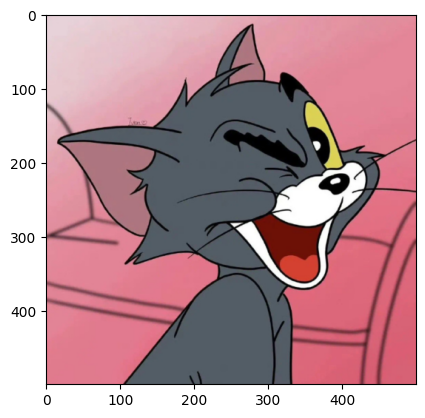

In [40]:
#图片处理
transform = T.Compose([
    T.Resize((500, 500)),
    T.ToTensor(),
])

img_tensor = transform(img)
print(img_tensor)
print(img_tensor.shape)
# plt.imshow()
img_numpy = img_tensor.permute(1, 2, 0).cpu().numpy()  #建议转换为numpy
plt.imshow(img_numpy)
print(img_numpy.shape)
print(type(img_numpy))

### 2.演示-自编码器-效果
#### 2.1 定义编码器模型

In [41]:
import torch.nn as nn


class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # 编码器
        self.encoded = None
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        # 解码器
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        self.encoded = encoded
        decoded = self.decoder(encoded)
        return decoded


# 测试
model = AutoEncoder()
input = torch.randn(1, 3, 256, 256)
# print(model)
output = model(input)
print(output.shape)

torch.Size([1, 3, 256, 256])


### 2.2 设置相关参数 (1.将模型移动到设备上 2.定义超参数 3.定义损失函数和优化器)

In [42]:
# 1.将模型移动到设备上
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(model)
# 2.定义超参数
lr = 1e-3
epoches = 200

# 3.定义损失函数和优化器
loss_f = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

AutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)


### 2.3 训练模型

In [43]:
def trainer(img_input,img_target):
    for epoch in range(epoches):
        model.train()
        input = img_input.to(device)
        target = img_target.to(device)

        output = model(input)
        loss_val = loss_f(output, target)
        loss_val.backward()

        optimizer.step()
        optimizer.zero_grad()

        if (epoch + 1) % 50 == 0:
            print(f"epoch:{epoch + 1}/{epoches},loss:{loss_val.item():.6f}")


trainer(img_tensor,img_tensor)

epoch:50/200,loss:0.052002
epoch:100/200,loss:0.033794
epoch:150/200,loss:0.011800
epoch:200/200,loss:0.008145


### 2.4 保存模型

In [44]:
torch.save(model.state_dict(), "./model/autoencoder.pth")

### 2.5测试训练图像

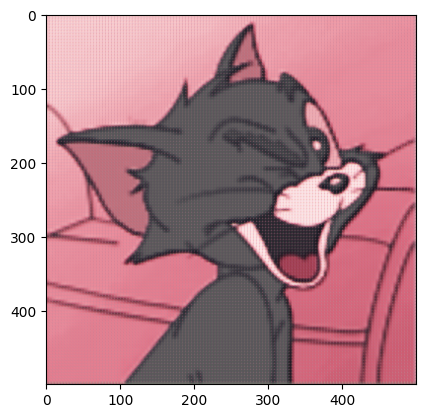

In [45]:
def test_img(img_test):
    with torch.no_grad():
        model.eval()
        input = img_test.to(device)
        output = model(input)
    img_numpy = output.detach().cpu().numpy()
    img_numpy = img_numpy.transpose((1, 2, 0))
    plt.imshow(img_numpy)
test_img(img_tensor)

### 3演示-去噪自编码器

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00016865134..1.4998901].


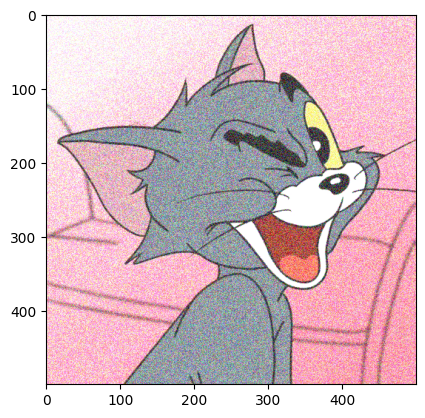

In [46]:
# 3.1加入噪声
img_noise = img_tensor + torch.rand_like(img_tensor) * 0.5
# 显示一下
img_numpy = img_noise.detach().permute(1, 2, 0).numpy()
plt.imshow(img_numpy)
plt.show()

epoch:50/200,loss:0.005384
epoch:100/200,loss:0.005176
epoch:150/200,loss:0.005015
epoch:200/200,loss:0.004868


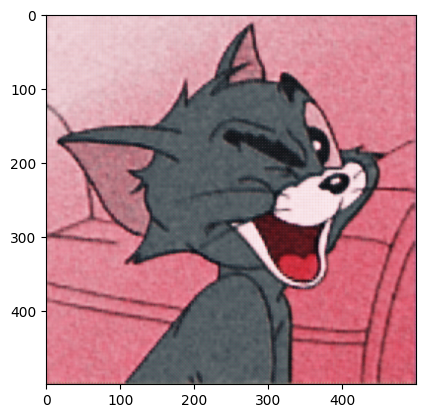

In [48]:
# 训练模型
trainer(img_noise,img_tensor)
# 测试结果
test_img(img_noise)